In [ ]:
# 2
import numpy as np                                                      # anything with numbers
import pandas as pd                                                     # anything with tables
import xarray as xr                                                     # geospatial data
import matplotlib.pyplot as plt                                         # make visuals

print("Ready!")

## *PART II: The Philippines as a Biodiversity Hotspot*

### Vegetation types & forest cover

Yesterday and this morning, we classified climate zones using [Köppen's system](https://en.wikipedia.org/wiki/K%C3%B6ppen_climate_classification) — and Köppen, originally a botanist, designed his thresholds specifically so that climate zones would line up with **vegetation zones** (Af regions look like rainforest, Aw regions look like savanna, and so on). In the next part, we look at *actual* vegetation data instead of using climate as a proxy for it.

We'll **zoom into Negros** and use the **[Hansen Global Forest Change dataset](https://storage.googleapis.com/earthenginepartners-hansen/GFC-2023-v1.11/download.html)** (Hansen et al., 2013, *Science* — 👉 https://doi.org/10.1126/science.1244693), which maps global tree cover and forest loss from satellite imagery at 30 m resolution. You can browse it interactively yourself at 👉 https://glad.earthengine.app/view/global-forest-change.

For now we only need the `treecover2000` variable (percent canopy cover in the year 2000) from `negros_forest_change.nc`. The file is under `../data/processed/day2/`

In [ ]:
# --- Load Negros forest cover data ---
forest_ds = xr.open_dataset("../data/processed/day2/negros_forest_change.nc")
forest_ds

**Inspect the data** with a 1x2 (one row, two columns) subplot. Left, you plot `treecover2000`, right, you plot `lossyear`:

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(10,5))                           # ✏️ initiate 1x2 subplot with figsize=(10,5)
forest_ds["treecover2000"].plot(ax=axes[0], cmap="Greens")              # ✏️ plot the treecover2000 variable from forest_ds, use cmap="Greens" as colormap
forest_ds["lossyear"].plot(ax=axes[1], cmap="Reds", vmin=1, vmax=23)    # ✏️ plot the lossyear variable from forest_ds, use cmap="Reds" as colormap

# don't bother with titles or layout, it's just a quick data inspection

> **Discussion:** What do you think the data represents? What is `treecover2000`, and what is `lossyear`? *Hint: the unit is 'years since 2000'*. You might also have noticed that **the figure above took a while to plot**. Why is that, you think?

The file has a very high resolution of 30m. How many data points are you plotting in the point above? **✏️ Calculate it below!**

In [ ]:
# Hint:
# number of data points = two variables x number of latitudes x number of longitudes
nr = 2 * len(forest_ds.latitude) * len(forest_ds.longitude)
nr

💡 If you got that right, you should see that, above, you are plotting **42 240 000 datapoints**, that's a lot. To make our lives a bit easier, let's reduce that **by coarsening it** a bit so maps stay fast to draw. Of course `xarray`&mdash;everyone's favourite library&mdash; has a built-in tool for that:

In [ ]:
treecover = forest_ds["treecover2000"]
treecover_coarse = treecover.coarsen(latitude=10, longitude=10, boundary="trim").mean()     # ✏️ what do you think specifying latitude=10, longitude=10 does?
treecover_coarse

**🖊️ How many datapoints does treecover_coarse contain?**

In [ ]:
# Hint: same as before, but only for treecover_coarse
nr = len(treecover_coarse.latitude) * len(treecover_coarse.longitude)
nr

*211 200 datapoints*, good, that's a lot less than before. Let's see if that plots a bit faster:

**🖊️ Plot the tree cover map and mark Bacolod.**

In [ ]:
#  visualize the tree cover data for Negros and mark Bacolod:
fig, ax = plt.subplots(figsize=(7, 7))                                  # ✏️ initialize fig, ax
treecover_coarse.plot(ax=ax, cmap="Greens", vmin=0, vmax=100,           # ✏️ plot treecover_coarse
                       cbar_kwargs={"label": "Tree cover 2000 (%)"})


# ✏️ use ax.scatter(...) and ax.text(...) to add a marker and label for Bacolod
# coordinates: 122.95, 10.68
ax.scatter(122.95, 10.68, color="black", s=60, zorder=5)                
ax.text(122.97, 10.69, "Bacolod", fontsize=9)
ax.set_title("Tree Cover — Negros (year 2000)")
ax.set_aspect("equal")

Way faster!

> **Discussion:** Where on the map is Negros most forested? Does that line up with the wetter (Af/Am) vs. drier (Aw) zones from Part I's homemade climate map?

**🖊️ Summary statistics:** For the entire figure, we can compute the **mean tree cover percentage** simply by using the `.mean()` method. Try it:

In [ ]:
mean_cover = float(treecover.mean())            # ✏️ use .mean() on the treecover variable
print(mean_cover)

💡 How could you compute the percentage of **pixels with more than 50% tree cover**?

It's super easy, but probably not intuitive for you just yet. Let's guide you through this with an example. Say we take some 2x2 array:

In [ ]:
some_array = np.array([[5, 3], [2, 8]])
some_array

**Where is it > 4?** You can see: first row, first column (number 5); and second row, second column (number 8). **See what this does:**

In [ ]:
some_array > 4

So that gives `True` where the values in some_array are > 4, and `False` where they are not.

In programming, `True` and `False` are often **synonymous** with `1` and `0`, and in this case, we can actually use it just like that, look:

In [ ]:
(some_array > 4).mean()

Two times True (1) and two times False (0) -> the mean is 0.5. So on average, 50% of the values in some_array are > 4. **All we have to do to get a percentage is multiply by 100**:

In [ ]:
my_percentage = (some_array > 4).mean() * 100

print(f"Hey look, {my_percentage}% of the values are greater than 4!")

**🖊️ Your turn: compute what percentage of Negros is forest.** Let's say a pixel with more than 50% tree cover is forest. From the `treecover` DataArray, compute the percentage of the image that meets this criterion:

In [ ]:
percentage_forest = (treecover > 50).mean() * 100           # ✏️ percentage of pixels with treecover > 50%

print(f"Pixels with >50% tree cover: {float(percentage_forest)}%")

> 💬 **Discussion:** Is this what you expected? A mean tree cover of about 12.5% and a mean forest cover of about 14%? It might be quite a bit lower than what you thought. Why? *(Hint: what area are we taking the mean over?)*

Let's take it up one notch and only compute forest cover over land by using the **land sea mask**. The file is called `land-sea-mask_0p00833333.nc` and is under `../data/processed/`:

In [ ]:
lsm = xr.open_dataarray("../data/processed/land-sea-mask_0p00833333.nc")    # ✏️ open with xr.open_dataarray()
lsm.plot()

At 1km resolution, the `lsm` DataArray for the Philippines shows where there's land (`True`, or `1`) and where there's ocean (`False` or `0`) — it's a **binary** mask. So now, **how can we use this map to cut out the tree cover data over land only?**

Again, `xarray` has this great built-in function called `.where()` where you can consider a DataArray, e.g. `treecover_coarse`, only where some specific requirement is met.

**For example**, if you're only interested in places where treecover is larger than 50%, you can do:

In [ ]:
treecover_coarse.where(treecover_coarse > 50).plot()

So if we only want to consider the tree cover data where there's land, i.e. where the land sea mask equals one, we should be able to do that with `.where()`, right?

Let's try it naively (a bit of foreshadowing, **this will raise an error**): 

In [ ]:
treecover.where(lsm==1).plot()

💥 **That error is worth reading closely.** `Unable to allocate 508. TiB for an array with shape (4800, 4400, 2040, 1620)...`

> **Discussion:** do you know where those numbers come from?

...

Those are `treecover`'s two dimensions *and* `lsm`'s two dimensions, all four kept separate and multiplied together: 4800 × 4400 × 2040 × 1620 ≈ **5.7 × 10¹³ values**.

There are pobably very little supercomputers in existence that are able to load that into memory, let alone your laptop or the free Google Colab servives.

Why did **xarray** do that instead of just lining the two grids up? Because it **matches dimensions by name**, not by what they represent — and `lsm`'s dimensions are called `lat`/`lon`, while `treecover`'s are called `latitude`/`longitude`. As far as xarray is concerned those are four completely unrelated axes, so it built every combination of every point in both grids instead of comparing them point-for-point.

**💡 The fix: put `lsm` on `treecover`'s exact grid first.** Of coarse, xarray can do that natively. Two steps — `.rename()` to match the dimension names, then `.interp()` to resample `lsm`'s values onto `treecover`'s coordinates.

In [ ]:
# ✏️ Regridding lsm onto treecover's exact grid
lsm_negros = lsm.rename({"lat": "latitude", "lon": "longitude"})        # ✏️ rename lon -> longitude

lsm_negros = lsm_negros.interp(latitude=treecover.latitude,             # ✏️ what latitudes do we want to map lsm to? Hint: treecover.latitude 
                               longitude=treecover.longitude,           # ✏️ what longitudes?
                               method="nearest")

lsm_negros.plot(cmap="Greys_r")

`lsm_negros` now has the exact same shape and dimension names as `treecover` (check: `lsm_negros.shape`). `.where()` can now compare the two point-for-point instead of guessing.

**🖊️ Your turn:** redo the masked plot, using `lsm_negros` instead of `lsm`.

In [ ]:
treecover.where(lsm_negros == 1).plot()   # ✏️ where do we want to plot the treecover data? Hint: where the regridded lsm_negros equals 1

> 💬 **Discussion:** Compare this to the very first tree-cover map you plotted. Did we successfully mask out the ocean pixels using the land sea mask?

Remember the earlier discussion — *"why is the mean tree cover only ~12.5%?"* Now that ocean pixels are properly masked, let's answer it directly.

**🖊️ Your turn:** compute `mean_cover_land`, the mean of `treecover`, masked to land only with `lsm_negros`.

In [ ]:
# Hint: start with treecover -> consider where the regridded lsm equals 1 -> take the mean
mean_cover_land = treecover.where(lsm_negros == 1).mean()   # ✏️ same .mean() as before, applied to the masked version

print(f"Mean tree cover, ocean excluded: {float(mean_cover_land):.1f}%")

> 💬 **Discussion:** That's noticeably higher than the raw ~12.5% you computed earlier — masking out ocean (which always reads 0% tree cover) was dragging the whole-image average down. General lesson, not just about forests: **always check what your average is actually averaging over.**

---

### Satellite imagery

**A lot of the data we have and use today is thanks to satellites**. What they observe is also **very relevant for a lot of biological applications**. For example, Hansen could never have created the global maps of forest data we used above if it weren't for satellites.

But what does a satellite actually "see"? There's generally two categories of satellites: **active and passive ones:**

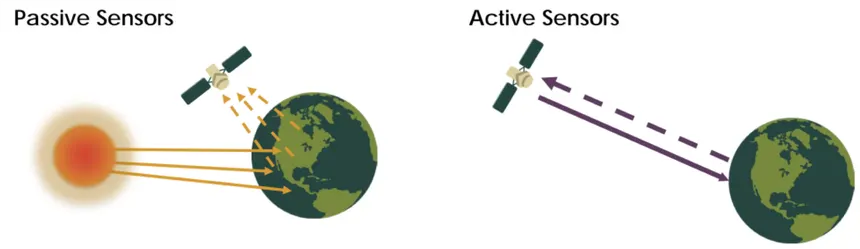

Passive sensors measure the light that is reflected or emitted by the Earth, whereas active sensors beam light towards the Earth and measure how much is reflected back. For every wavelength of the electromagnetic spectrum (light) they measure, they store data in grids of numbers, very much like the data we have used before.

We'll use the **[Sentinel-2](https://sentinel.esa.int/web/sentinel/missions/sentinel-2)** mission (ESA/Copernicus): two satellites launched in 2015 and 2017 that jointly revisit every point on Earth every ~5 days, at 10-60 m resolution. **🖊️ Open the file** `negros_sentinel2.nc` under `../data/processed/day2/`and see what's inside.

In [ ]:
s2_ds = xr.open_dataset("../data/processed/day2/negros_sentinel2.nc")   # ✏️ open the Sentinel-2 data with xr.open_dataset
s2_ds

> **Discussion:** What variables are inside the dataset? What coordinates does it have?

There are **two dates** (`2018-02-09` and `2024-04-03`) and **five variables** available in the dataset.
- **Active measurements**, the satellite beams these to the Earth and measures how much reflects back:
  1. `red`,
  2. `nir` (near-infrared)
- **Passive measurements**, the satellite measures how much of these are reflected by the Earth (coming from the sun):
  1. `visual_r` (red),
  2. `visual_g` (green),
  3. `visual_b` (blue).

The human eye sees (red, green, blue) — if you plot the three passive measurements together you get a ready-made true-colour image (what your eyes would actually see).

**🖊️ Plot the active** `red` **for** `time="2024-04-03"`:

In [ ]:
# --- Load Sentinel-2 data ---
red_new = s2_ds["red"].sel(time="2024-04-03")       # ✏️ Hint: index the "red" variable -> use .sel(...) to select the "2024-04-03" timestamp for the time coordinate

fig, ax = plt.subplots(figsize=(6, 6))
red_new.plot(ax=ax, cmap="Reds")

ax.set_title("Red band only — just one number per pixel")
ax.set_aspect("equal")

> **Discussion:** What do you notice about the red band? What type of surface reflects a lot of red light?

**🖊️ Data quality check:** This is satellite data, and not a ready-made, cleaned dataset. What percentage of values in `red_new` are NaNs?

Hints: remember xarray's `shape`, `np.isnan` and `np.sum`

In [ ]:
# ✏️ Compute the percentage of pixels that has a missing value
# Hint: sum of NaNs / total number of pixels * 100
np.sum(np.isnan(red_new)) / np.prod(red_new.shape) * 100

If you got the above right, you should see that the data is about **0.29% NaNs**&mdash;that's very little. **To get an actual photo-like image**, we need to **combine** the three passive bands (**red, green, blue**) into a single array of shape `(rows, cols, 3)` — one extra dimension holding the 3 colour channels for every pixel. `np.dstack` stacks 2D arrays along a new third axis to do exactly this:

In [ ]:
# =============================================================
# 💡 EXAMPLE — stacking 2D arrays into a 3D array
# =============================================================

array_1 = np.array([[1, 2, 3], [4, 5, 6]])
print(array_1.shape)

array_2 = np.array([[7, 8, 9], [10, 11, 12]])
print(array_2.shape)

# use np.dstack to stack the two arrays, creating a third dimension
array_3 = np.dstack([array_1, array_2])
print(array_3.shape)

> **Discussion:** How many rows and columns do `array_1` and `array_2` have? How many dimensions does `array_3` have?

**🖊️ Try extracting** `array_2` back from `array_3`, this will help you understand the dimensions:

In [ ]:
extracted = array_3[:, :, 1]   # ✏️ remember how to index?

# if you did that correctly, this should be all be True:
extracted == array_2

**Great!** Now we understand how `np.dstack` works, we can use it to stack our three passive satellite bands! **🖊️ Complete the code below:**

In [ ]:
s2_new = s2_ds.sel(time="2024-04-03")     # ✏️ select the 2024-04-03 timestamp from s2_ds. Hint: .sel(...)

# s2_new is a xarray Dataset
# extract the values of the three visual bands:

r = s2_new["visual_r"].values       # ✏️ Visual red values. Hint: index the "visual_r" variable from s2_new and get its values with .values
g = s2_new["visual_g"].values       # ✏️ Visual green values.
b = s2_new["visual_b"].values       # ✏️ Visual blue values.

# 💡 plt.imshow doesn't like NaNs.
# -> we can use np.nan_to_num to replace NaNs with 0s
r = np.nan_to_num(r)
g = np.nan_to_num(g)
b = np.nan_to_num(b)

rgb_new = np.dstack([r, g, b])      # ✏️ use np.dstack to stack the three arrays!
print("rgb_new shape:", rgb_new.shape)

# Plotting stuff
rgb_new = rgb_new.astype(np.uint8)
fig, ax = plt.subplots(figsize=(7, 7))
ax.imshow(rgb_new)          # 💡 imshow displays a (rows, cols, 3) array directly as a photo
ax.set_title("True-colour image — Negros, 2024")
ax.axis("off")

> **Discussion:** Cool! A satellite image. Are there any things you notice? Can we observe all of the land surface in this image? 

### 2018 versus 2024, side by side

Build the same kind of true-colour image for the **2018** ("old") time slice, and plot it next to the 2024 image you already have — a two-panel figure, same subplot skills as yesterday.

**Tips:**
- The "old" date is `"2018-02-09"`
- Reuse `rgb_new` (already built above) for the right-hand panel

In [ ]:
# --- Build the "old" (2018) true-colour image ---
s2_old = s2_ds.sel(time="2018-02-09")                   # ✏️ pick the 2018 date from s2_ds

# ✏️ extract the values of the three visual bands:
r_old = s2_old["visual_r"].values
g_old = s2_old["visual_g"].values
b_old = s2_old["visual_b"].values

# ✏️ replace NaNs with zeros using np.nan_to_num:
r_old = np.nan_to_num(r_old)
g_old = np.nan_to_num(g_old)
b_old = np.nan_to_num(b_old)

# ✏️ stack the three arrays
rgb_old = np.dstack([r_old, g_old, b_old])

# --- Two-panel comparison ---
rgb_old = rgb_old.astype(np.uint8)
fig, axes = plt.subplots(1, 2, figsize=(13, 7))

axes[0].imshow(rgb_old)         # ✏️ imshow the rgb_old on the first axes
axes[0].set_title("2018")

axes[1].imshow(rgb_new)         # ✏️ imshow the rgb_new on the second axes
axes[1].set_title("2024")

for ax in axes:
    ax.axis("off")

fig.suptitle("Negros, Sentinel-2 true colour — 2018 vs. 2024")

> 💬 **Discussion:** Looks like 2018 contains a lot more missing data then 2024. But besides that, what visible changes can you spot between 2018 and 2024, just by eye? Can you point out forest, farmland, urban areas, and coastline in the images — and does what you see line up with what you'd expect from the `treecover2000` map, and from Bacolod's known location?

---

### Fauna

Climate and vegetation set the stage — now let's look at who actually lives there. We'll use occurrence records from **[GBIF](https://www.gbif.org/)** (the Global Biodiversity Information Facility), **a free, public database aggregating millions of species sightings** and museum specimens worldwide from thousands of institutions.

Two flagship species first:
- **[Philippine Eagle](https://en.wikipedia.org/wiki/Philippine_eagle)** (*Pithecophaga jefferyi*) — one of the world's largest and rarest eagles, endemic to the Philippines, Critically Endangered, and entirely forest-dependent. 👉 https://www.gbif.org/species/2480381
- **[Large flying fox](https://en.wikipedia.org/wiki/Large_flying_fox)** (*Pteropus vampyrus*) — one of the largest bats in the world, found across the Philippine archipelago. 👉 https://www.gbif.org/species/5218644

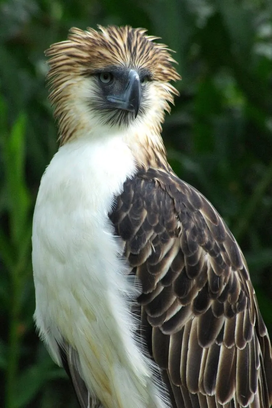
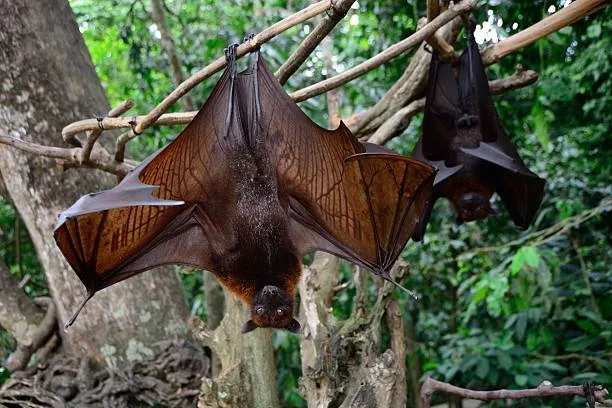

In [ ]:
# --- Load occurrence records ---
eagle = pd.read_csv("../data/processed/day2/gbif_philippine_eagle.csv")     # ✏️ gbif_philippine_eagle.csv under ../data/processed/day2/
flying_fox = pd.read_csv("../data/processed/day2/gbif_flying_fox.csv")      # ✏️ gbif_flying_fox.csv, same directory

# ✏️ display first few rows of eagle DataFrame
eagle.head()

> **Discussion:** What columns do the `eagle` and `flying_fox` data have?

🖊️ How many sightings are there for the two species? You know how to get this by now!

In [ ]:
print(f"Philippine Eagle records: {len(eagle)}")    # ✏️ print the amount of Philippine Eagle sightings
print(f"Flying fox records: {len(flying_fox)}")     # ✏️ print the amount of Flying Fox sightings

### Mapping the sightings

Let's see where these species have been spotted! We can do this easily with `ax.scatter`. However, up until now we've only used `ax.scatter` to mark Bacolod on the map. 

**💡 Quick illustration**:


In [ ]:
lat = [8, 2, 3, 2.5, 7]                 # random values
lon = [120, 125, 130, 135, 140]         # random values

fig, ax = plt.subplots()
ax.scatter(lat, lon)                    # 💡 you can pass arrays to .scatter(...), not just individual values!

🖊️ Let's make a **1x2 subplot** and use `.scatter(...)` to mark the Philippine Eagle observations on the **left** panel, and the Large Flying Fox observations on the **right** panel. We'll also use the 1km resolution `land-sea-mask_0p00833333.nc` from `../data/processed/` to outline the Phillipines.

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8))         # ✏️ 1x2, figsize 12x8

axes[0].scatter(eagle["lon"], eagle["lat"],             # ✏️ how do we pass the "lon" and "lat" columns from the eagle DataFrame?
                color="firebrick", s=20, alpha=0.7)     

axes[1].scatter(flying_fox["lon"], flying_fox["lat"],   # ✏️ same for the flying_fox
                color="steelblue", s=20, alpha=0.7)     


axes[0].set_title(f"Philippine Eagle ({len(eagle)} records)")   # ✏️ include the number of records in the title
axes[1].set_title(f"Flying Fox ({len(flying_fox)} records)")    # ✏️ include the number of records in the title

lsm = xr.open_dataarray("../data/processed/land-sea-mask_0p00833333.nc")

for ax in axes:
    ax.contourf(lsm.lon, lsm.lat, lsm.values,                   # ✏️ pass the land-sea mask lon, lat, and values to ax.contourf(...) <- makes a filled contour
               levels=[0.75, 1.25], colors=["#666666"],
               linewidths=0.8, alpha=0.2)
    ax.set_xlabel("Longitude")
    ax.set_aspect("equal")

axes[0].set_ylabel("Latitude")

> 💬 **Discussion:** What patterns do you notice in the observation records of the Philippine Eagle and flying fox? The eagle is entirely forest-dependent and Critically Endangered, do you see that reflected in the data?

---

Two species is a start, but let's look at a much richer picture: **every terrestrial mammal record for the Philippines** in GBIF.

The file is `gbif_mammals_philippines.csv` under `../data/processed/day2/`:

In [ ]:
# --- Load the full mammal community dataset ---
mammals = pd.read_csv("../data/processed/day2/gbif_mammals_philippines.csv")    # ✏️ open gbif_mammals_philippines.csv

# ✏️ display first few rows
mammals.head()

> **Discussion:** How many columns does the `mammals` DataFrame have?

**🖊️ Further inspect the data.** How many total sightings are there? How many unique species are recorded? Hint: you can use pandas' `.nunique()` on the `"species"` column.

In [ ]:
nr_rec = len(mammals)               # ✏️ you know how to do this. Hint: len()
print(f"{nr_rec} records.")

unique_species = mammals['species'].nunique()   # ✏️ Hint: use .nunique() on the "species" column of the mammals DataFrame
print(f"{unique_species} species")

**🖊️ Which mammal groups dominate?**

Use `.value_counts()` on the `order` column to see which taxonomic groups have the most records.

In [ ]:
order_counts = mammals["order"].value_counts()     # ✏️ use .value_counts() on the "order" column of mammals
print(order_counts)

> 💬 **Discussion:** Which order dominates, and by how much? Does that match what you'd naively guess about "Philippine mammals"? *Think about how easy each group is to survey. Record counts reflect sampling effort as much as true abundance!*

---

### Data quality check

Before we filter and plot, let's check how complete the columns we're about to rely on actually are — real-world biodiversity data is rarely 100% populated, and it's good practice to check *before* you filter on a column, not after.

**🖊️ Check for missing values** in the `county`column using `.isnull()`

In [ ]:
# ✏️ Check how many values are missing in the "county" column of the mammals DataFrame
nr_missing = mammals["county"].isnull().sum()          # Hint: use .isnull() to check for missing values, then add .sum() to sum them up
print(f"{nr_missing} missing values")

# ✏️ what percentage of the "county" column is missing?
# 💡 same trick as before: True=1/False=0, so .mean() = fraction missing
perc_missing = mammals['county'].isnull().mean() * 100  # Hint: .isnull(), then .mean(), then multiply by 100 to get percentage
print(f"{perc_missing:.1f}% missing")                   

**🖊️ Check null rates** on the columns we're about to use

We're about to filter records to Negros using `stateProvince`, and later make a bar chart of `iucnRedListCategory`. **Check the missing-value fraction for both**, plus `family` and `order`:

In [ ]:
columns_to_check = ["stateProvince", "iucnRedListCategory", "family", "order"]

# ✏️ use a for loop to iterate over columns_to_check
for col in columns_to_check:
    perc_missing = mammals[col].isnull().mean() * 100     # ✏️ .isnull() followed by .mean() and multiplied by 100

    print(f"{col:20s}: {perc_missing:5.1f}% missing")

> 💬 **Discussion:** `stateProvince` and `iucnRedListCategory` both have a meaningful chunk of missing values, while `family`/`order` are essentially complete. What does that mean for the filtering and bar chart we're about to make?

---

### Filtering to Negros

`stateProvince` isn't perfectly clean text — a look at the raw values shows entries like `"Negros Oriental"`, `"Negros Occidental"`, `"Negros I"`, `"Negros Id."`. Rather than matching one exact string, we can check whether `"Negros"` appears *anywhere* in the text using `.str.contains()`:

In [ ]:
# 7 random strings and a missing value in a pandas Series:
random_strings = pd.Series(["Myles", "Workshop day 2", "Crocodiles", np.nan, "What is a bird?", "Sunday", "One day I'll understand programming", "Sydje is chasing Mellie again"])

# 💡 using .str.contains() to filter rows by a partial text match 
random_strings.str.contains("day",          # -> check if the string "day" is present in each element of the Series
                            case=False,     # -> ignore case. So it doesn't matter if it's Day or DAY or day, it will still match
                            na=False)       # -> treat missing values as "no match"

> **Discussion:** What would the output be if we just looked for the letter "s" instead of for "day"?

`.str.contains()` returns binary `True` / `False` -> *Aha!* Then we can **use it for indexing**!

In [ ]:
contains_str = random_strings.str.contains("day",           # ✏️ toy around with the search string
                                            case=False,     
                                            na=False)
random_strings[contains_str]

**🖊️ Your turn:** filter the mammal records to Negros, and map them

**Tips:**
- Same pattern as the example, applied to `mammals["stateProvince"]`
- Use `mammals[is_negros]` to keep only the matching rows (same boolean-filtering idea as yesterday's `df[condition]`)
- Reuse the scatter + `land_sea_mask.nc` contour pattern from the eagle/flying fox map — but this time, zoom the axes to Negros using `ax.set_xlim(122.3, 123.4)` and `ax.set_ylim(9.8, 11.0)` (the same bounding box as the Sentinel-2/Hansen data)

In [ ]:
is_negros = mammals["stateProvince"].str.contains("Negros",     # ✏️ what are we looking for? Hint: "Negros"
                                                  case=False,   # ✏️ case insensitive
                                                  na=False)     # ✏️ NaNs = no match

negros_mammals = mammals[is_negros]               # ✏️ as we did above!

In [ ]:
fig, ax = plt.subplots(figsize=(7, 8))
ax.scatter(negros_mammals["decimalLongitude"], negros_mammals["decimalLatitude"],
           color="purple", s=30, alpha=0.5)
ax.contour(lsm.lon, lsm.lat, lsm.values,
           levels=[0.5], colors=["#666666"], linewidths=0.8, alpha=0.7)

ax.set_xlim(122.3, 123.4)   # ✏️ FIRST don't set xlim, THEN cut to (122.3, 123.4)
ax.set_ylim(8.9, 11.0)      # ✏️ FIRST don't set ylim, THEN cut to (8.9, 11.0)

# annotate the locations that occur over 10 times in the data with their total count
counts = (
    negros_mammals.groupby(["decimalLongitude", "decimalLatitude"])
    .size()
    .reset_index(name="count")
)

repeated = counts[counts["count"] > 10]

for _, row in repeated.iterrows():
    ax.scatter(row["decimalLongitude"], row["decimalLatitude"],
               color="black", s=15, zorder=6)
    ax.text(row["decimalLongitude"] + 0.01, row["decimalLatitude"] + 0.01,
            str(int(row["count"])), fontsize=8, color="black", zorder=7)



ax.set_title(f"Mammal occurrence records — Negros (total: {len(negros_mammals)})")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_aspect("equal")

> 💬 **Discussion:** Notice the points scattered far outside Negros itself (even outside the Philippines!) if you check `negros_mammals["decimalLongitude"].describe()` — a good reminder that a `stateProvince` text match isn't a perfect filter; some records are simply mislabeled or mis-geocoded. Real data always needs this kind of scrutiny. At some locations, there's more than 100 observations. **What do you think of the geographical distribution of observations in Negros?**

### Conservation status bar chart

Let's check how many animals belong to the different **conservation status categories**! We'll make a bar chart of `iucnRedListCategory` value counts for the Negros mammal subset.

The **[IUCN Red List](https://www.iucnredlist.org/)** categorises extinction risk from least to most severe: **LC** (Least Concern) → **NT** (Near Threatened) → **VU** (Vulnerable) → **EN** (Endangered) → **CR** (Critically Endangered), plus **DD** (Data Deficient — not enough information to assess).

**Tip:**
- `.value_counts()` on `negros_mammals["iucnRedListCategory"]` gives you **counts per category** directly

In [ ]:
iucn_counts = negros_mammals["iucnRedListCategory"].value_counts()    # ✏️ negros_mammals["iucnRedListCategory"].value_counts()
iucn_counts

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(iucn_counts.index, iucn_counts.values, color="darkorange")   # ✏️ x: iucn_counts.index. y: iucn_counts.values

ax.set_title("IUCN Red List Category — Negros mammal records")
ax.set_xlabel("Category")
ax.set_ylabel("Number of records")

> **Discussion:** To what category to most of the observed species belong? Notice that there's quite some in the `DD` category (data deficient), why do you think that is?

**🖊️ Look up** some of the specific `species` behind the EN/CR/VU records on Negros. What species are they? What threatens them?

In [ ]:
# Step 1: binary (True / False) of where the category is EN/CR/VU
is_threatened = negros_mammals["iucnRedListCategory"].isin(["EN", "CR", "VU"])      # ✏️ Hint: apply .isin(["...", "...", "..."]) to negros_mammals["iucnRedListCategory"]

# Step 2: use your binary to filter negros_mammals
filtered = negros_mammals[is_threatened]["species"]     # ✏️ index negros_mammals with is_threatened, then index to the "species" column

# Step 3: use .unique() to get the unique species names
unique_threatened_species = filtered.unique()       # ✏️ use .unique() on filtered to get the unique species names

print(unique_threatened_species)

> **Discussion:** Does this match what you already know from your biology studies? What vulnerable, endangered and critically endangered species did we find in this dataset? What do you think are the causes for their conservation status? **Nine species** identified that belong to EN/CR/VU categories in Negros. Do you think that is **accurate?**

**💥 CHALLENGE 💥** Do the same as in the cell above, but in one line of code:

In [ ]:
# [OPTIONAL] ✏️ do what the cell above did, but in one line
print(negros_mammals[negros_mammals["iucnRedListCategory"].isin(["EN", "CR", "VU"])]["species"].unique())

---

### Your own biodiversity map

**Biodiversity** is not such a straightforward concept. Biologists, like yourself, often distinguish between different levels such as **genetic diversity**, **species diversity**, **species abundance**, **ecosystem diversity**, ... With the `mammals` DataFrame, we have a bunch of georeferenced observations. The easiest ways of translating that to biodiveristy are probably species *diversity and abundance*. **Let's go for the former.**

We already worked with the Hansen tree cover data, which is a grid in which the value in each pixel is the percentage of the pixel that is covered by trees. What if we could make something like that ourselves, but for mammal biodiversity? Let's do that: **let's make a grid in which each pixel value is the total number of unique species observed**.

There's a bit of a difficulty: as we saw earlier, if we keep the exact locations and just sum the unique species at every exact location, the biodiversity at one place will be different from another place just 10m away, which is unrealistic. With a small `pandas` trick we can fix that: **by slightly rounding coordinates**, we turn scattered points into a **grid**, and then we can count **unique** values per grid cell.

**💡 Trick #1 — rounding turns points into a grid.** Two GPS coordinates are almost never *exactly* equal, even for animals spotted right next to each other — one extra decimal of precision and they look like different locations. But if we **round** every coordinate to the same number of decimal places, nearby points collapse onto the same rounded value. That shared rounded value becomes a grid cell.

In [ ]:
# =============================================================
# 💡 EXAMPLE — rounding coordinates builds a grid
# =============================================================
toy = pd.DataFrame({
    "species": ["eagle", "eagle", "flying_fox", "tarsier", "flying_fox"],
    "lon":     [122.92,  122.93,  122.94,        124.60,    124.62],            # <- coordinates with 2 decimal points
    "lat":     [10.68,   10.67,   10.66,         9.70,      9.71],
})

toy["lon_grid"] = toy["lon"].round(1)   # <- make a new column "lon_grid" that is a copy of "lon" but rounded to 1 decimal value
toy["lat_grid"] = toy["lat"].round(1)   # <- same for "lat"
toy

> Discussion: Look at the `lon` column versus the `lon_grid` column. Do you see how the first three observations, which have different exact locations, now share the same grid point?

**Rounding to 1 decimal** place groups points within roughly **~10 km** of each other into the same cell.

**Let's apply the same trick to the real `mammals` table!**

First, a data-quality step: a handful of records sit way outside the Philippines. Let's filter those out. By now you probably already know the drill: first you make some binary condition, then you filter the DataFrame rows using that condition. To cut `mammals` to the Philippines, we need to filter both `lon` and `lat`.

Time for you to learn something new: filtering two conditions at once using `&`, and using `.between()` to allow a range of values:

In [ ]:
# 💡 .between() to allow a range of values
# 💡 & means 'AND' -> you have to meet condition 1 AND condition 2
condition = toy["lon_grid"].between(122.8, 123.0) & toy["lat_grid"].between(10, 11)
print(condition)

toy[condition]

**🖊️ Your turn:** Keep only records inside a generous Philippines bounding box before gridding, using `.between()` and `&` to filter both `decimalLongitude` and `decimalLatitude` at the same time:
- Philippines bounding box: longitude **116–127°E**, latitude **4.5–21.5°N**
- Round `decimalLongitude`/`decimalLatitude` to 1 decimal place, same as the toy example, into new columns named `lon_grid` / `lat_grid`

In [ ]:
# ✏️ filter mammals both on decimalLongitude and decimalLatitude
in_philippines = mammals["decimalLongitude"].between(116, 127) & mammals["decimalLatitude"].between(4.5, 21.5)   # ✏️ Look at the example above! Double condition

mammals_ph = mammals[in_philippines]        # ✏️ use in_philippines to index mammals

print(f"{len(mammals)} records -> {len(mammals_ph)} after dropping out-of-bounds points")

# ✏️ same rounding trick as the toy example above
mammals_ph["lon_grid"] = mammals_ph["decimalLongitude"].round(1)   # ✏️ new column "lon_grid" that is a copy of "decimalLongitude" but rounded to 1 decimal value
mammals_ph["lat_grid"] = mammals_ph["decimalLatitude"].round(1)    # ✏️ same for "lat_grid" and "decimalLatitude"

mammals_ph.head()

**💡 Trick #2 — counting *unique* species per grid cell.**

You've already used `.value_counts()` to count *records*. What we want now is **subtly different**: per grid cell, how many *different* species were seen — a cell with 3 records of the same species shouldn't score higher than a cell with 2 records of 2 different species.

`.pivot_table()` builds exactly this kind of grid in one call: a row grouping, a column grouping, a value to summarize, and how to summarize it — here, `"nunique"`, short for *number of unique values*:

In [ ]:
# =============================================================
# 💡 EXAMPLE — pivot_table: row grouping x column grouping -> one summary value
# =============================================================
toy_richness = toy.pivot_table(index="lat_grid",        # -> group by the "lat_grid" column
                               columns="lon_grid",      # -> group by the "lon_grid" column
                               values="species",        # -> we want to aggregate the "species" column
                               aggfunc="nunique")       # -> how? With the number of unique species in each lat_grid x lon_grid combination
toy_richness

Both cells come out to **2** — cell `(10.7, 122.9)` had 3 records but only 2 distinct species (eagle, eagle, flying_fox); cell `(9.7, 124.6)` had 2 records and 2 distinct species (tarsier, flying_fox). `pivot_table` + `"nunique"` counted *species*, not *sightings*.

**🖊️ Your turn:** build the real richness grid — same call, real data.

- Same `pivot_table()` shape as above: `index="lat_grid"`, `columns="lon_grid"`, `values="species"`, `aggfunc="nunique"`
- Apply it to `mammals_ph`, and call the result `richness_ph`

In [ ]:
biodiversity = mammals_ph.pivot_table(index="lat_grid",      # ✏️ use pivot_table on mammals_ph!
                                     columns="lon_grid",   
                                     values="species",
                                     aggfunc="nunique")

print(f"Grid shape: {biodiversity.shape}, richest cell: {int(biodiversity.max().max())} species")
biodiversity

> **Discussion:** Richest 10x10km pixel has a total count of 47 unique mammal species. Do you think that is representative of the biodiversity in the Philippines?

**💡 One more ingredient — the same forest-cover data, for the whole country.**

You already know how to load and coarsen Hansen tree-cover data — you did exactly this for Negros, at the very start of Part II. `forest_cover_philippines_1km.nc` is the same dataset and variable, just for the whole archipelago. Two differences to watch for: its coordinates are named `lat`/`lon` here instead of `latitude`/`longitude`, and its native pixel size is different, so the coarsening factor needs adjusting to land on roughly the same ~0.1° cells as `biodiversity` (native pixels are ~0.0083°, so ~12 of them make up ~0.1°).

Load it, coarsen it, then we'll put both maps side by side.

In [ ]:
treecover_ph_ds = xr.open_dataset("../data/processed/forest_cover_philippines_1km.nc")      # ✏️ forest_cover_philippines_1km.nc in ../data/processed/
treecover_ph = treecover_ph_ds["treecover2000"]     # ✏️ select the "treecover2000" variable from treecover_ph_ds

# ✏️ same .coarsen() call as treecover_coarse earlier
treecover_ph_coarse = treecover_ph.coarsen(lat=12,      # ✏️ coarsen lat 12x
                                           lon=12,      # ✏️ coarsen lon 12x
                                           boundary="trim").mean()
treecover_ph_coarse

In [ ]:
# --- Two-panel comparison: species richness vs. tree cover, whole Philippines ---
fig, axes = plt.subplots(1, 2, figsize=(13, 8))

# 💡 given — pivot_table's output isn't an xarray DataArray, so we plot it with pcolormesh instead of .plot()
mesh = axes[0].pcolormesh(biodiversity.columns.values, biodiversity.index.values, biodiversity.values,
                           cmap="viridis", shading="nearest")
fig.colorbar(mesh, ax=axes[0], label="Unique species recorded", shrink=0.7)
axes[0].set_title("Mammal species richness (GBIF)")

treecover_ph_coarse.where(treecover_ph_coarse > 0).plot(ax=axes[1], cmap="Greens", vmin=0, vmax=100,
                         cbar_kwargs={"label": "Tree cover 2000 (%)"})   # ✏️ same .plot() call as treecover_coarse, right at the start of Part II
axes[1].set_title("Tree cover (Hansen)")

for ax in axes:
    # plot lsm contourf
    ax.contourf(lsm.lon, lsm.lat, lsm.values,
                levels=[0.75, 1.25], colors=["#666666"],
                linewidths=0.8, alpha=0.2)
    ax.set_xlim(116, 127)
    ax.set_ylim(4.5, 21.5)
    ax.set_aspect("equal")

> 💬 **Discussion:** Where does the richness map light up brightest — does it track the tree-cover map, or does it look more like "wherever a biologist happened to visit"? Compare the hotspots to the sampling-bias pattern you already noticed in the eagle/flying-fox maps earlier in this Part. **A high-richness cell can mean real biodiversity, or it can just mean someone was there recording things** — with presence-only data like this, the map alone can't always tell you which.

---

## Well done — Part II complete!

You just:
- Connected yesterday's climate classification to actual vegetation and forest cover data
- Learned to build true-colour images from raw satellite bands (`np.dstack`)
- Compared satellite imagery across time, by eye
- Worked with real, messy biodiversity occurrence data (GBIF): filtering, null-checking, and conservation-status reporting
- Built your own species-richness grid from scratch (`round` + `pivot_table`) and used it to ask whether biodiversity tracks forest cover across the whole country

Next: **Part III**, where we go from satellite imagery to an actual land use classification.

## *PART III: From satellite imagery to land use*

Köppen designed his climate thresholds around vegetation zones; now let's flip that around and classify *land cover itself* directly from the Sentinel-2 imagery you already loaded in Part II — using the exact same recipe as Part I's homemade climate classifier: turn a decision rule into a `def` function, apply it to a whole grid at once, and map the result.

### 1) NDVI: turning two bands into one meaningful number

**Healthy, lush-green vegetation absorbs a lot of red light but reflects a lot of near-infrared**. Remember that we had these two bands available in our Sentinel-2 imagery? We can combine them in the [Normalized Difference Vegetation Index NDVI](https://en.wikipedia.org/wiki/Normalized_difference_vegetation_index), the most widely used metric to derive vegetation status from remote sensing data. NDVI is computed as:

**NDVI = (NIR − Red) / (NIR + Red)**

NDVI ranges from -1 to +1: strongly **negative** for water, **near zero** for bare soil/urban surfaces, and **high** (often >0.3) for healthy vegetation. Let's write a small reusable function for it: